<a href="https://colab.research.google.com/github/Ritesh-Gawande/Machine-Learning-Code/blob/main/SVM_LoanApproval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
!pip install ydata-profiling

In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
from ydata_profiling import ProfileReport
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder,OrdinalEncoder
import warnings
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
import pickle
#from sklearn.pipeline import Pipeline
%matplotlib inline
warnings.filterwarnings('ignore')

In [25]:
from google.colab import files
uploaded = files.upload()

In [26]:
df = pd.read_csv('loan_approved.csv')

In [27]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved)
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [28]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved)
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Loan_ID                 614 non-null    object 
 1   Gender                  601 non-null    object 
 2   Married                 611 non-null    object 
 3   Dependents              599 non-null    object 
 4   Education               614 non-null    object 
 5   Self_Employed           582 non-null    object 
 6   ApplicantIncome         614 non-null    int64  
 7   CoapplicantIncome       614 non-null    float64
 8   LoanAmount              592 non-null    float64
 9   Loan_Amount_Term        600 non-null    float64
 10  Credit_History          564 non-null    float64
 11  Property_Area           614 non-null    object 
 12  Loan_Status (Approved)  614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [30]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [31]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [32]:
profile=ProfileReport(df,title="EDA",explorative=True)
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 13/13 [00:00<00:00, 26.05it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [43]:
profile.to_file('report.html')

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

<Axes: >

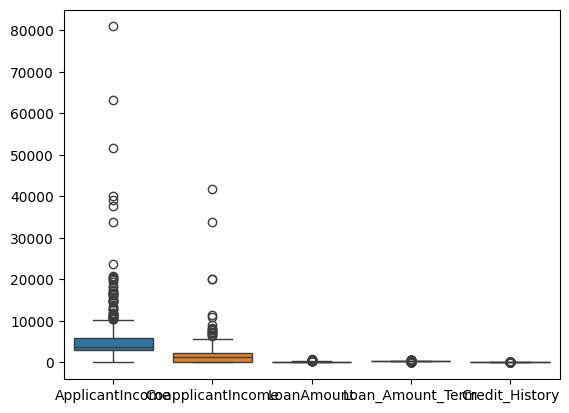

In [34]:
figsize=(10,40)
sns.boxplot(df)

<Axes: ylabel='ApplicantIncome'>

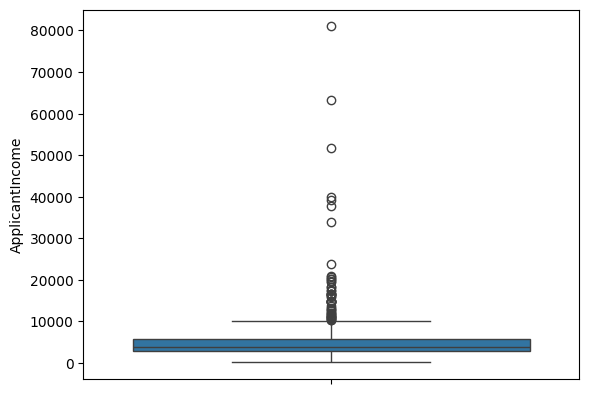

In [35]:
sns.boxplot(df.ApplicantIncome)

In [36]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area',
       'Loan_Status (Approved)'],
      dtype='object')

In [37]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [38]:
df.loc[df['Gender'].isnull(),'Gender']= df.Gender.unique()[0]
df.loc[df['Married'].isnull(),'Married']= df.Married.unique()[0]
df.loc[df['Dependents'].isnull(),'Dependents']= '0'
df.loc[df['Self_Employed'].isnull(),'Self_Employed']= df.Self_Employed.unique()[0]
df.loc[df['LoanAmount'].isnull(),'LoanAmount']= df.LoanAmount.mean()
df.loc[df['Loan_Amount_Term'].isnull(),'Loan_Amount_Term']= df.Loan_Amount_Term.unique()[0]
df.loc[df['Credit_History'].isnull(),'Credit_History'] = df.Credit_History.unique()[0]

In [39]:
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [40]:
df.ApplicantIncome.unique()

array([ 5849,  4583,  3000,  2583,  6000,  5417,  2333,  3036,  4006,
       12841,  3200,  2500,  3073,  1853,  1299,  4950,  3596,  3510,
        4887,  2600,  7660,  5955,  3365,  3717,  9560,  2799,  4226,
        1442,  3750,  4166,  3167,  4692,  3500, 12500,  2275,  1828,
        3667,  3748,  3600,  1800,  2400,  3941,  4695,  3410,  5649,
        5821,  2645,  4000,  1928,  3086,  4230,  4616, 11500,  2708,
        2132,  3366,  8080,  3357,  3029,  2609,  4945,  5726, 10750,
        7100,  4300,  3208,  1875,  4755,  5266,  1000,  3333,  3846,
        2395,  1378,  3988,  2366,  8566,  5695,  2958,  6250,  3273,
        4133,  3620,  6782,  2484,  1977,  4188,  1759,  4288,  4843,
       13650,  4652,  3816,  3052, 11417,  7333,  3800,  2071,  5316,
        2929,  3572,  7451,  5050, 14583,  2214,  5568, 10408,  5667,
        2137,  2957,  3692, 23803,  3865, 10513,  6080, 20166,  2014,
        2718,  3459,  4895,  3316, 14999,  4200,  5042,  6950,  2698,
       11757,  2330,

## steps of preprocessing
1. Label encoder on Gender, Married, Education
2. Ordinal Encoding on Dependents
3. OHE on Property Area, Self_emp
4. FunctionTransformer for Loan_Amount_term
5. Standard scaler for Applicant Income , CoapplicantIncome and LoanAmount
6. Credit hist will passthrugh

## Steps of preprocessing for Target/Label
1. LabelEncoder for Loan_Status (Approved)

In [41]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area',
       'Loan_Status (Approved)'],
      dtype='object')

In [48]:
OHE_col = ['Property_Area','Self_Employed']
SS_col = ['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term']
LE_col_1 = ['Gender']
LE_col_2 = ['Married']
LE_col_3 = ['Education']
LE_col_Target = ['Loan_Status (Approved)']
function_trasformer_col=["Loan_Amount_Term"]
Ordinal_col = ['Dependents']
pass_through_col=['Credit_History']

dependents_enc = OrdinalEncoder(categories=[['0', '1', '2', '3+']])


In [49]:
class ModifiedLabelEncoder(LabelEncoder):
    def fit_transform(self, y, *args, **kwargs):
        return super().fit_transform(y).reshape(-1, 1)

    def transform(self, y, *args, **kwargs):
        return super().transform(y).reshape(-1, 1)

In [50]:
def div_by_30(x):
    return x/30
custom = FunctionTransformer(div_by_30)

In [51]:
def same(x):
    return x
passthru = FunctionTransformer(same)

In [52]:
preprocessor = ColumnTransformer([('OHE',OneHotEncoder(),OHE_col),
                                  ('SS',StandardScaler(),SS_col),
                                  ('FT',custom,function_trasformer_col),
                                  ('LE',ModifiedLabelEncoder(),LE_col_1,LE_col_2,LE_col_3),
                                  ('do_nothing',passthru,pass_through_col),
                                  ('OE1',dependents_enc,['Dependents']),
                                  ('Target',ModifiedLabelEncoder(),LE_col_Target)])

In [53]:
preprocessor

ColumnTransformer(transformers=[('OHE', OneHotEncoder(),
                                 ['Property_Area', 'Self_Employed']),
                                ('SS', StandardScaler(),
                                 ['ApplicantIncome', 'CoapplicantIncome',
                                  'LoanAmount', 'Loan_Amount_Term']),
                                ('FT',
                                 FunctionTransformer(func=<function div_by_30 at 0x7e73d691fc40>),
                                 ['Loan_Amount_Term']),
                                ('LE', ModifiedLabelEncoder(), ['Gender'],
                                 ['Married'], ['Education']),
                                ('do_nothing',
                                 FunctionTransformer(func=<function same at 0x7e73d72b44a0>),
                                 ['Credit_History']),
                                ('OE1',
                                 OrdinalEncoder(categories=[['0', '1', '2',
                                                             '3+']]),
                                 ['Dependents']),
                                ('Target', ModifiedLabelEncoder(),
                                 ['Loan_Status (Approved)'])])

In [54]:
with open('SVM_CT.pkl','wb') as f:
    pickle.dump(preprocessor,f)
    f.close

In [55]:
with open('Processed_data.pkl','wb') as f:
    pickle.dump(df,f)
    f.close